creating lightning days based on flashrate 

In [1]:
import xarray as xr
import os
import re
import glob
import xclim

In [2]:
# import config
import tomllib as tomli
with open(r"C:\Users\CAMG038492\Code\Climatology\config.toml","rb") as f:
    conf = tomli.load(f) # Loads configuration settings from a TOML file.

datahome = conf['paths']['datahome']
originalinput = conf['paths']['originalinput'] # Local path template where downloaded files are stored. Placeholders **p and **s refer to parameter and scenario, respectively. Loads from config.toml.

testpath = r"C:\Data\flashrate\historical\originals\CESM2\flashrate_Emon_CESM2-WACCM_historical_r1i1p1f1_gn_185001-201412.nc"

In [35]:
df = xr.open_dataset(testpath)

c:\Users\CAMG038492\AppData\Local\miniforge3\envs\climate\Lib\site-packages\xarray\conventions.py:204: SerializationWarning: variable 'flashrate' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


In [50]:
df['flshann'] = df.flashrate * 60 * 60 * 24 * 360
mean = df.flshann.mean(dim = 'time')

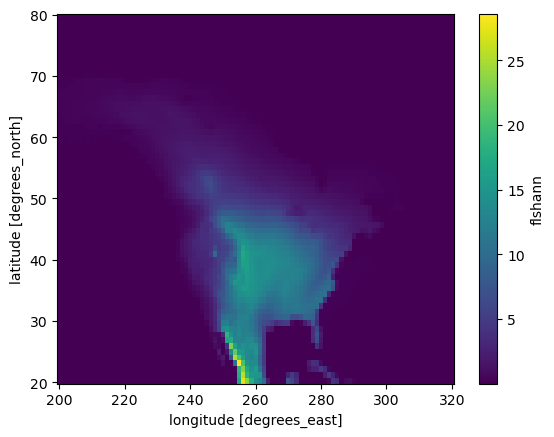

In [51]:
mean = mean.sel(lat = slice(20,80), lon = slice(200,320))
mean.plot()